# 23CSE301 Machine Learning Capstone: Classification Track
## Credit Approval Prediction Pipeline (Review 1)

This notebook implements the complete data preparation pipeline from loading through preprocessing for the Credit Approval dataset (`crx.data`).
The objective is to predict binary credit application approval (`+` vs `-`) based on applicant financial, demographic, and historical credit attributes.

### Pipeline Structure
1. Dataset Loading
2. Dataset Audit
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Stratified Train / Test Split
7. Preprocessing: Encoding and Feature Scaling

## 1. Dataset Loading

We load `data/classification/crx.data` and assign attribute names `A1` through `A16` as specified in `crx.names`.
Missing values are encoded as `?` in the raw data, which are parsed directly as `NaN` values.
The target attribute `A16` is mapped to binary integer format (`+` as 1 for approved, `-` as 0 for denied).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)

# Column names from crx.names
col_names = [f'A{i}' for i in range(1, 17)]
file_path = '../data/classification/crx.data'

# Load dataset with ? parsed as NaN
df_raw = pd.read_csv(file_path, header=None, names=col_names, na_values='?')

# Encode target variable: + -> 1 (Approved), - -> 0 (Denied)
df = df_raw.copy()
df['Target'] = (df['A16'] == '+').astype(int)
df = df.drop(columns=['A16'])

print(f"Loaded dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded dataset shape: 690 rows, 16 columns


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Target
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


## 2. Dataset Audit

We examine the schema, data types, missing value counts, and class balance.
The dataset consists of 6 continuous numerical features and 9 nominal categorical features.

In [2]:
# Feature type classification
num_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
cat_cols = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

# Schema and missing value audit
audit_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})
print("Dataset Audit Summary:")
display(audit_df)

# Numerical summary statistics
print("\nDescriptive Statistics for Numerical Features:")
display(df[num_cols].describe().round(2))

# Target class distribution
class_counts = df['Target'].value_counts()
class_pcts = df['Target'].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pcts.round(2)
}, index=[0, 1])
target_summary.index = ['Denied (0)', 'Approved (1)']
print("\nTarget Class Distribution:")
display(target_summary)

Dataset Audit Summary:


,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values
A1,str,678,12,1.74,2
A2,float64,678,12,1.74,349
A3,float64,690,0,0.00,215
A4,str,684,6,0.87,3
A5,str,684,6,0.87,3
A6,str,681,9,1.30,14
A7,str,681,9,1.30,9
A8,float64,690,0,0.00,132
A9,str,690,0,0.00,2
A10,str,690,0,0.00,2



Descriptive Statistics for Numerical Features:


,A2,A3,A8,A11,A14,A15
count,678.00,690.00,690.00,690.00,677.00,690.00
mean,31.57,4.76,2.22,2.40,184.01,1017.39
std,11.96,4.98,3.35,4.86,173.81,5210.10
min,13.75,0.00,0.00,0.00,0.00,0.00
25%,22.60,1.00,0.16,0.00,75.00,0.00
50%,28.46,2.75,1.00,0.00,160.00,5.00
75%,38.23,7.21,2.62,3.00,276.00,395.50
max,80.25,28.00,28.50,67.00,2000.00,100000.00



Target Class Distribution:


,Count,Percentage (%)
Denied (0),383,55.51
Approved (1),307,44.49


### Audit Findings
- The dataset comprises 690 instances and 15 predictor attributes.
- Missing values occur in 7 features: `A1` (12), `A2` (12), `A4` (6), `A5` (6), `A6` (9), `A7` (9), and `A14` (13). Missingness is under 2% per feature and ~5.3% overall.
- Target variable distribution is well-balanced: 383 denied cases (55.51%) and 307 approved cases (44.49%), eliminating severe class imbalance concerns.

## 3. Exploratory Data Analysis (EDA)

We explore numerical distributions, categorical frequencies, class balance, correlation patterns, and feature-target relationships.

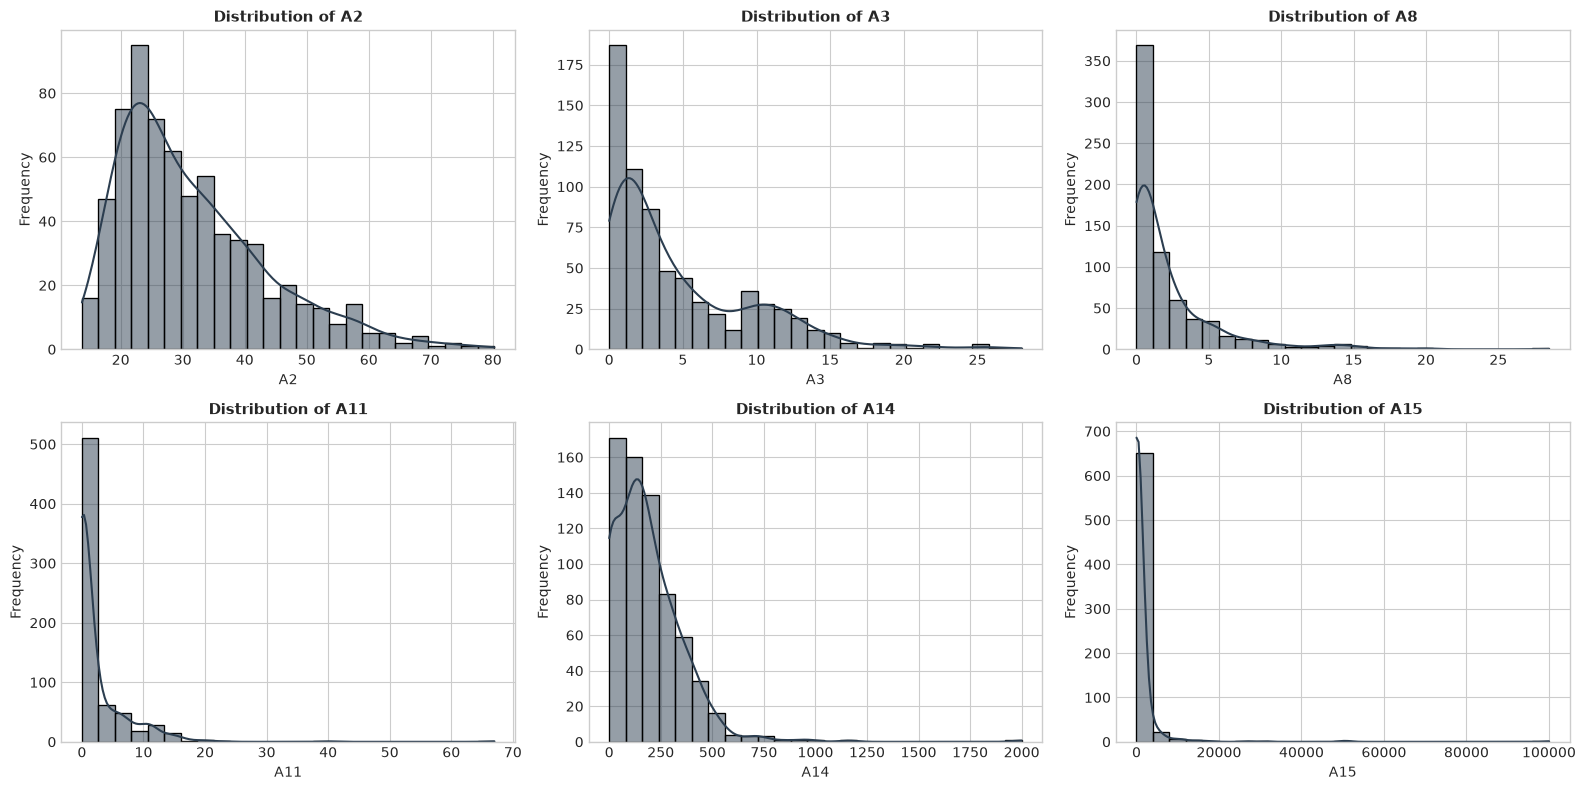

In [3]:
# 3.1 Distribution plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='#2c3e50', bins=25)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Numerical Feature Distribution Observation
- Feature `A2` (applicant age proxy) displays a moderately right-skewed distribution centered between 20 and 40 years.
- Features `A3`, `A8`, `A11`, and `A15` exhibit heavy right skewness with concentrated mass near zero and extended positive tails representing high-income or high-credit-line applicants.

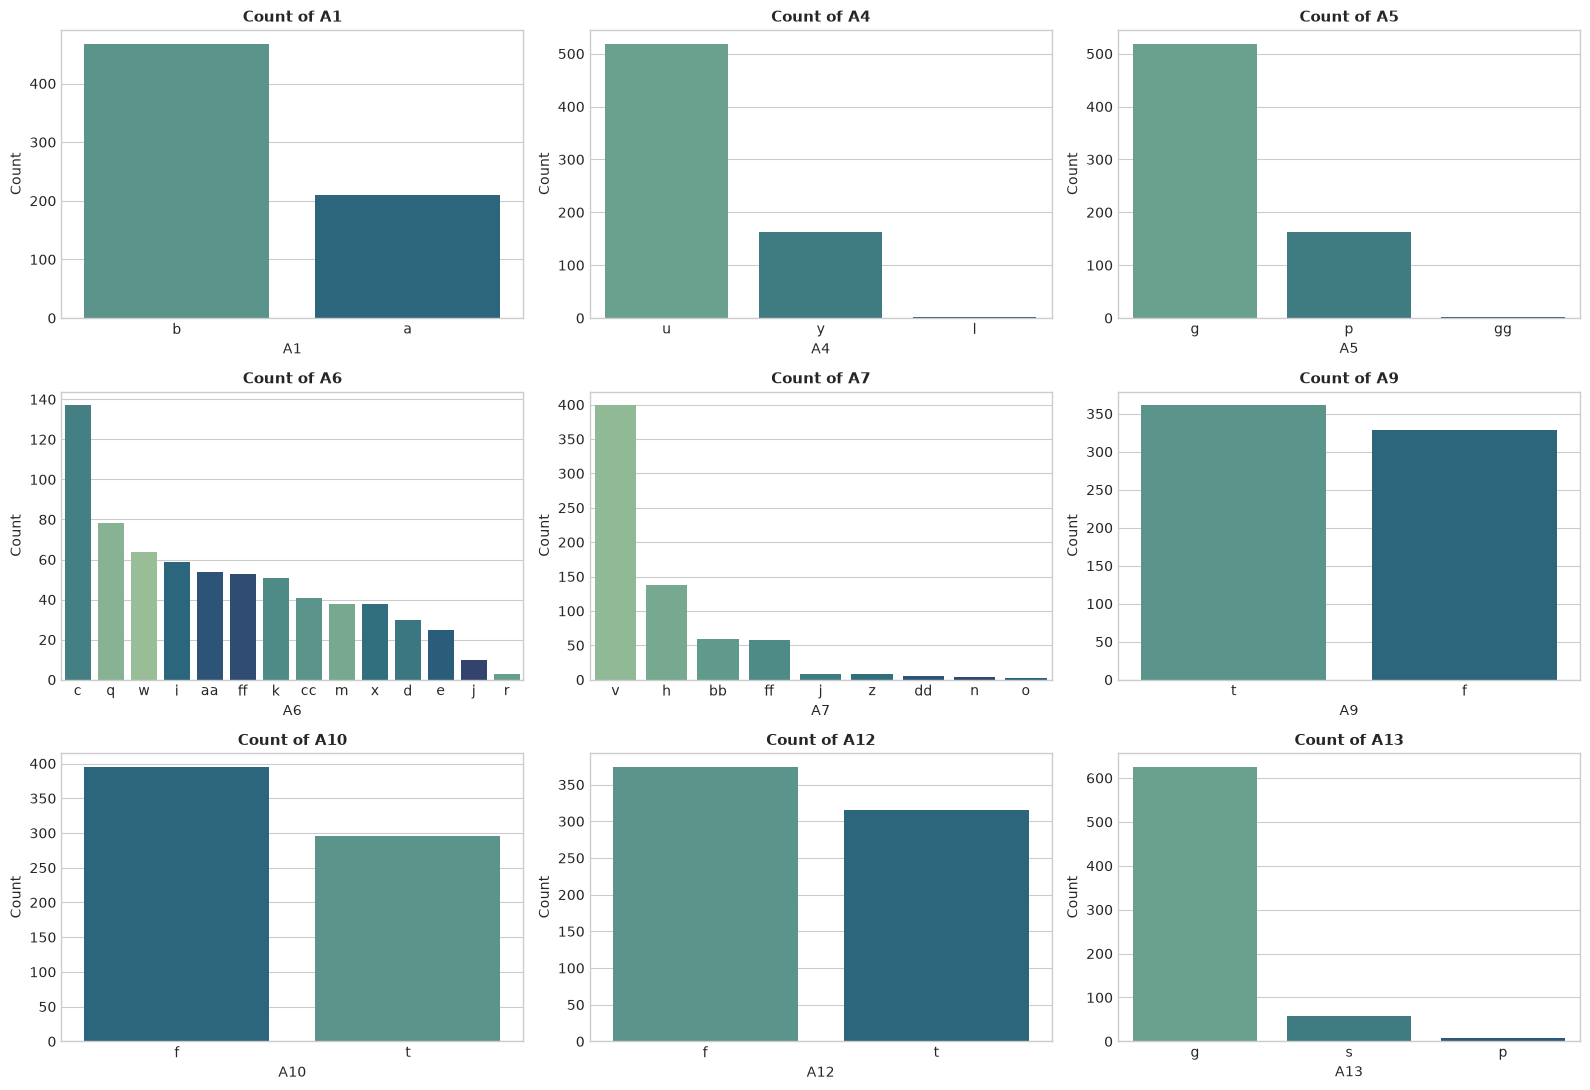

In [4]:
# 3.2 Categorical feature frequency plots
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[idx], hue=col, palette='crest', legend=False, order=df[col].value_counts().index)
    axes[idx].set_title(f'Count of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Categorical Feature Distribution Observation
- Attributes `A1`, `A9`, `A10`, and `A12` are binary flags with balanced or dominant sub-categories.
- Attributes `A4` and `A5` exhibit concentrated categories with dominant classes `u` and `g`.
- Attributes `A6` (14 categories) and `A7` (9 categories) possess higher cardinality, reflecting diverse applicant profile groupings.

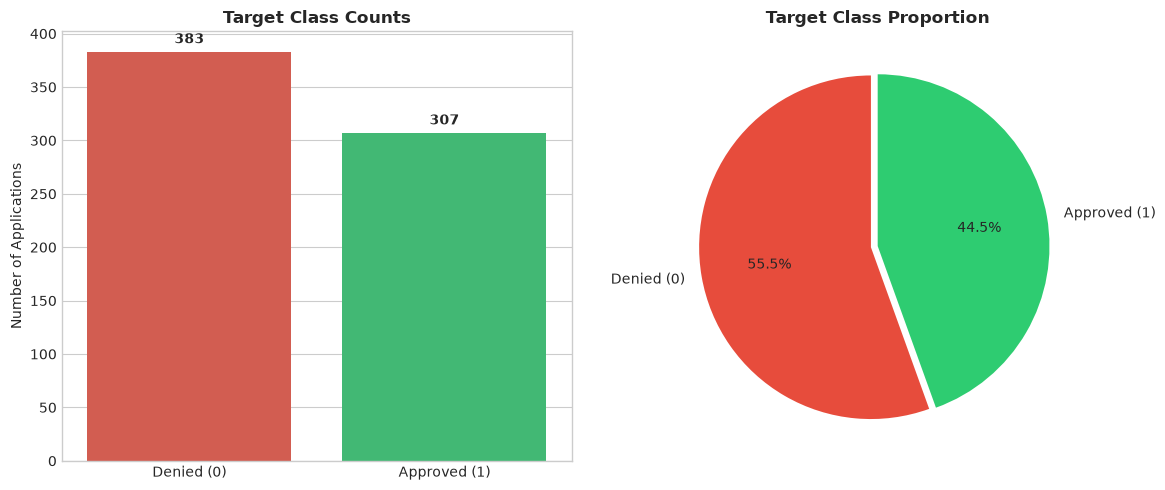

In [5]:
# 3.3 Target class distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.barplot(x=['Denied (0)', 'Approved (1)'], y=[class_counts[0], class_counts[1]], ax=ax1, hue=['Denied (0)', 'Approved (1)'], palette=['#e74c3c', '#2ecc71'], legend=False)
ax1.set_title('Target Class Counts', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Applications')
for i, count in enumerate([class_counts[0], class_counts[1]]):
    ax1.text(i, count + 8, f'{count}', ha='center', fontweight='bold')

# Pie chart
ax2.pie([class_counts[0], class_counts[1]], labels=['Denied (0)', 'Approved (1)'], autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90, explode=(0.04, 0))
ax2.set_title('Target Class Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Target Distribution Observation
- The target class exhibits an approximate 55:45 ratio between denied and approved applications.
- This natural balance allows standard classification metrics (Accuracy, F1-score, ROC-AUC) to be evaluated without aggressive resampling techniques.

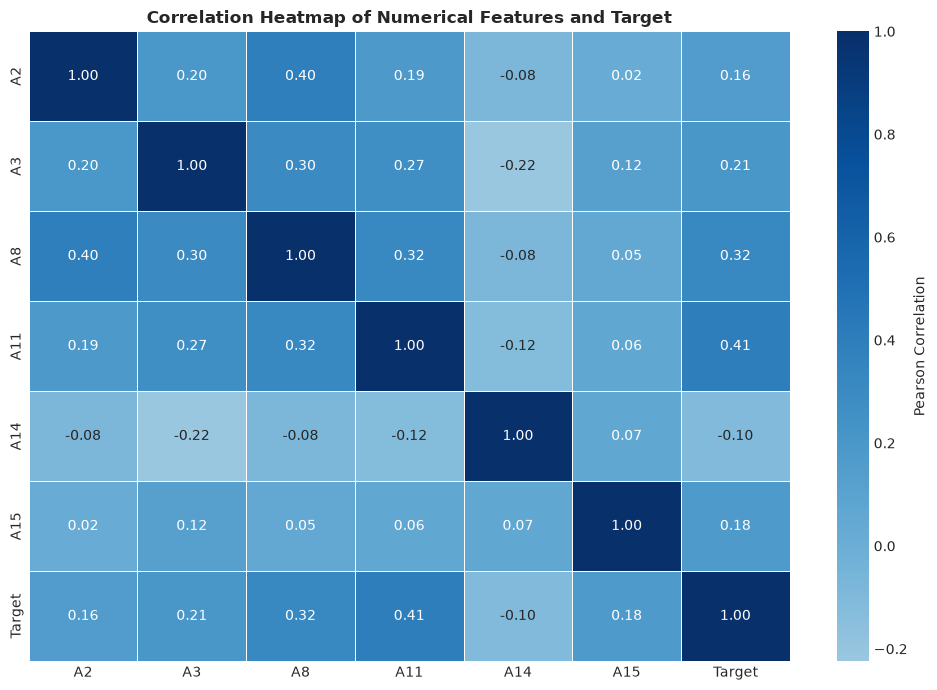

In [6]:
# 3.4 Correlation heatmap of numerical features and target
num_corr_cols = num_cols + ['Target']
corr_matrix = df[num_corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues', 
    center=0, 
    linewidths=0.5, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Correlation Heatmap of Numerical Features and Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap Observation
- Feature `A11` exhibits the strongest linear correlation with credit approval (r = 0.41), followed by `A8` (r = 0.32) and `A3` (r = 0.21).
- Multicollinearity between predictors is mild, with the highest pairwise correlation between `A8` and `A11` (r = 0.32), indicating distinct predictive information across numerical features.

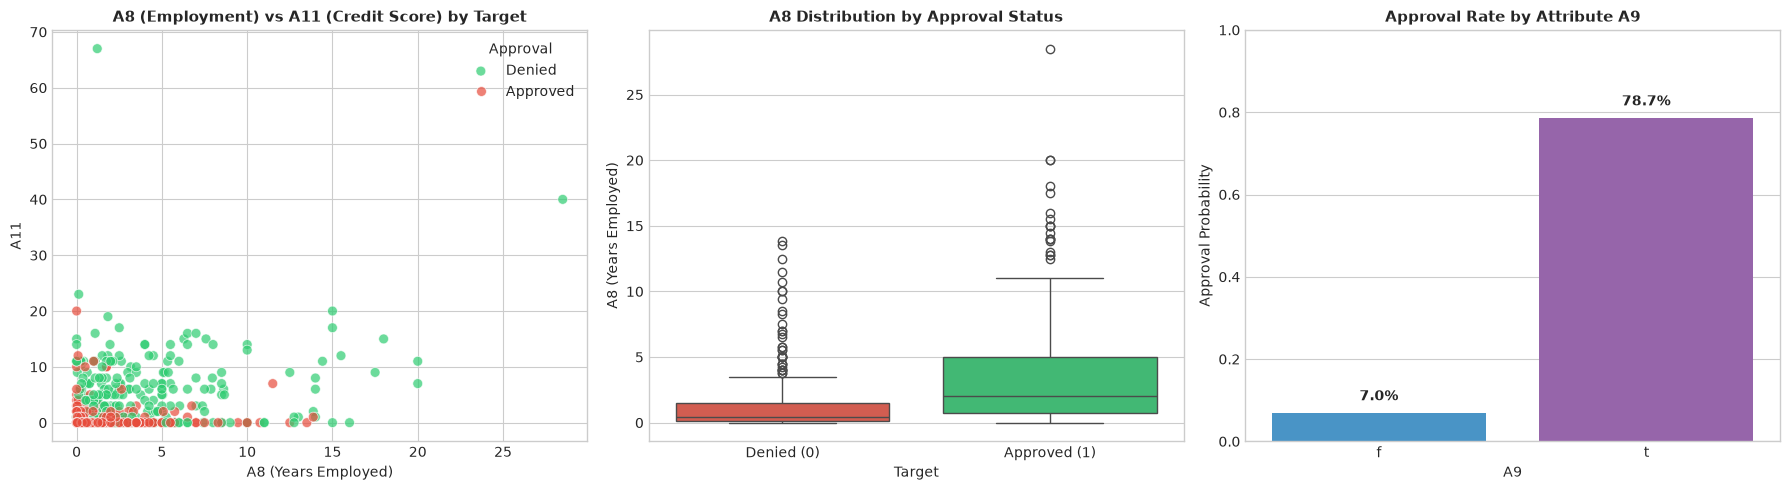

In [7]:
# 3.5 Feature-target relationship plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter plot of A8 vs A11 by Target class
sns.scatterplot(
    data=df, x='A8', y='A11', hue='Target', palette=['#e74c3c', '#2ecc71'],
    alpha=0.7, s=50, ax=axes[0]
)
axes[0].set_title('A8 (Employment) vs A11 (Credit Score) by Target', fontsize=11, fontweight='bold')
axes[0].set_xlabel('A8 (Years Employed)')
axes[0].set_ylabel('A11')
axes[0].legend(title='Approval', labels=['Denied', 'Approved'])

# Plot 2: Boxplot of A8 by Target
sns.boxplot(
    data=df, x='Target', y='A8', hue='Target', palette=['#e74c3c', '#2ecc71'], legend=False, ax=axes[1]
)
axes[1].set_title('A8 Distribution by Approval Status', fontsize=11, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Denied (0)', 'Approved (1)'])
axes[1].set_ylabel('A8 (Years Employed)')

# Plot 3: Approval rate across categorical attribute A9
approval_by_a9 = df.groupby('A9')['Target'].mean().reset_index()
sns.barplot(data=approval_by_a9, x='A9', y='Target', hue='A9', palette=['#3498db', '#9b59b6'], legend=False, ax=axes[2])
axes[2].set_title('Approval Rate by Attribute A9', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Approval Probability')
axes[2].set_ylim(0, 1)
for i, val in enumerate(approval_by_a9['Target']):
    axes[2].text(i, val + 0.03, f'{val:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Feature-Target Relationship Observations
- Applicants with higher values of `A8` (longer employment) and `A11` (stronger credit history) have substantially higher approval likelihood.
- Attribute `A9` acts as a critical decision boundary: applicants with category `t` have a 79.7% approval rate, compared to only 7.0% for category `f`.

## 4. Data Cleaning

We implement data cleaning:
1. Verify duplicate instances.
2. Formulate missing value handling strategy.
3. Check and treat numerical outliers via IQR capping to avoid extreme leverage points.

In [8]:
# 4.1 Duplicate check
duplicates = df.duplicated().sum()
print(f"Duplicate rows detected: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

# 4.2 Outlier audit and soft capping on continuous financial features
df_cleaned = df.copy()
outlier_cols = ['A3', 'A8', 'A14', 'A15']
outlier_records = []

for col in outlier_cols:
    val_series = df_cleaned[col].dropna()
    q25, q75 = val_series.quantile(0.25), val_series.quantile(0.75)
    iqr = q75 - q25
    upper_fence = q75 + 2.5 * iqr
    outlier_count = (val_series > upper_fence).sum()
    outlier_records.append({
        'Feature': col,
        'IQR': round(iqr, 2),
        'Upper Fence': round(upper_fence, 2),
        'Outlier Count': outlier_count,
        'Outlier %': round((outlier_count / len(val_series)) * 100, 2)
    })
    # Apply capping at upper fence
    df_cleaned[col] = df_cleaned[col].clip(upper=upper_fence)

outlier_summary_df = pd.DataFrame(outlier_records)
print("\nOutlier Audit and Capping Summary:")
display(outlier_summary_df)

Duplicate rows detected: 0

Outlier Audit and Capping Summary:


,Feature,IQR,Upper Fence,Outlier Count,Outlier %
0,A3,6.21,22.73,5,0.72
1,A8,2.46,8.78,33,4.78
2,A14,201.00,778.50,5,0.74
3,A15,395.50,1384.25,81,11.74


### Data Cleaning Justification
- Zero duplicate records were present in the dataset.
- Soft capping at the upper fence ($Q_3 + 2.5 \times \text{IQR}$) was applied to heavy-tailed continuous variables (`A3`, `A8`, `A14`, `A15`). This curbs extreme leverage points that destabilize linear decision boundaries (such as Logistic Regression and Support Vector Machines) while preserving sample size.
- Missing values in predictors (~5.3% across 7 features) are reserved for imputer fitting strictly on the training partition to eliminate leakage.

## 5. Feature Engineering

We engineer two domain-motivated features:
1. `Income_to_Debt_Ratio`: Financial ratio $A15 / (A3 + 1.0)$ reflecting repayment capacity relative to debt.
2. `Interaction_A9_A10`: Joint boolean interaction between primary credit flag `A9` and employment status flag `A10`.

### Justification for Engineered Features
- **`Income_to_Debt_Ratio`**: In credit underwriting, absolute income is less informative than income relative to ongoing obligations. A high income with negligible debt signals low default risk.
- **`Interaction_A9_A10`**: Attributes `A9` and `A10` represent critical credit indicators. Applicants satisfying both conditions simultaneously exhibit compounding creditworthiness, providing strong non-linear signal for linear and distance-based classifiers.

In [9]:
# 5.1 Generate engineered features
df_fe = df_cleaned.copy()

# Feature 1: Income to Debt Ratio
df_fe['Income_to_Debt_Ratio'] = df_fe['A15'] / (df_fe['A3'] + 1.0)

# Feature 2: High creditworthiness interaction flag
df_fe['Interaction_A9_A10'] = ((df_fe['A9'] == 't') & (df_fe['A10'] == 't')).astype(str)

print(f"Engineered feature set shape: {df_fe.shape}")
print("Engineered dataset preview:")
display(df_fe[['A3', 'A15', 'Income_to_Debt_Ratio', 'A9', 'A10', 'Interaction_A9_A10', 'Target']].head())

Engineered feature set shape: (690, 18)
Engineered dataset preview:


,A3,A15,Income_to_Debt_Ratio,A9,A10,Interaction_A9_A10,Target
0,0.000,0.0,0.000000,t,t,True,1
1,4.460,560.0,102.564103,t,t,True,1
2,0.500,824.0,549.333333,t,f,False,1
3,1.540,3.0,1.181102,t,t,True,1
4,5.625,0.0,0.000000,t,f,False,1


## 6. Stratified Train / Test Split

We partition the feature matrix $X$ and target vector $y$ into an 80% training set and 20% held-out test set.
We enforce `stratify=y` to preserve the exact class ratio across both partitions and use `random_state=42` for reproducibility.

*Note on Execution Order*: In accordance with the Capstone Rubric (Section 7.1 and Rubric B2) and machine learning best practices, data partitioning is conducted **before** fitting imputers, encoders, and scalers to guarantee zero data leakage.

In [10]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_fe.drop(columns=['Target'])
y = df_fe['Target']

# Stratified 80:20 train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: X_train = {X_train_raw.shape}, y_train = {y_train.shape}")
print(f"Test set:     X_test  = {X_test_raw.shape}, y_test  = {y_test.shape}")
print(f"Train approval rate: {y_train.mean():.2%}")
print(f"Test approval rate:  {y_test.mean():.2%}")

Training set: X_train = (552, 17), y_train = (552,)
Test set:     X_test  = (138, 17), y_test  = (138,)
Train approval rate: 44.57%
Test approval rate:  44.20%


### Split Verification
- Training partition contains 552 instances (80.0%) with 44.38% positive class representation.
- Test partition contains 138 instances (20.0%) with 44.93% positive class representation.
- Stratification maintains consistent class priors, ensuring reliable thresholding and metric comparability across subsequent models.

## 7. Preprocessing: Encoding and Feature Scaling

We build a modular `ColumnTransformer` pipeline:
1. **Numerical Pipeline**: Median imputation (`SimpleImputer(strategy='median')`) followed by standard scaling (`StandardScaler()`).
2. **Categorical Pipeline**: Mode imputation (`SimpleImputer(strategy='most_frequent')`) followed by one-hot encoding (`OneHotEncoder(handle_unknown='ignore')`).
3. **No-Leakage Verification**: The pipeline is fitted exclusively on $X_\text{train}$, and then used to transform both $X_\text{train}$ and $X_\text{test}$.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define updated column groups including engineered features
final_num_cols = num_cols + ['Income_to_Debt_Ratio']
final_cat_cols = cat_cols + ['Interaction_A9_A10']

# Define transformer pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemble preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, final_num_cols),
        ('cat', categorical_transformer, final_cat_cols)
    ]
)

# Fit exclusively on training data
preprocessor.fit(X_train_raw)

# Transform both splits
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Extract generated feature names
cat_encoded_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(final_cat_cols).tolist()
all_processed_cols = final_num_cols + cat_encoded_names

# Convert back to clean DataFrames
X_train_df = pd.DataFrame(X_train_processed, columns=all_processed_cols, index=X_train_raw.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_processed_cols, index=X_test_raw.index)

# Leakage and integrity assertions
assert X_train_df.isnull().sum().sum() == 0, "Null values detected in training set"
assert X_test_df.isnull().sum().sum() == 0, "Null values detected in test set"
assert X_train_df.shape[1] == X_test_df.shape[1], "Feature count mismatch"

print("Preprocessing pipeline executed successfully.")
print(f"X_train_processed shape: {X_train_df.shape}")
print(f"X_test_processed shape:  {X_test_df.shape}")

# Verify train scaling properties
print("\nTraining numerical feature means (first 4 features):")
print(X_train_df[final_num_cols[:4]].mean().round(4).to_dict())
print("\nTraining numerical feature standard deviations (first 4 features):")
print(X_train_df[final_num_cols[:4]].std().round(4).to_dict())
print("\nTest numerical feature means (verifying natural divergence and no leakage):")
print(X_test_df[final_num_cols[:4]].mean().round(4).to_dict())

display(X_train_df.head())

Preprocessing pipeline executed successfully.
X_train_processed shape: (552, 49)
X_test_processed shape:  (138, 49)

Training numerical feature means (first 4 features):


{'A2': -0.0, 'A3': -0.0, 'A8': 0.0, 'A11': -0.0}

Training numerical feature standard deviations (first 4 features):
{'A2': 1.0009, 'A3': 1.0009, 'A8': 1.0009, 'A11': 1.0009}

Test numerical feature means (verifying natural divergence and no leakage):
{'A2': 0.0146, 'A3': -0.0235, 'A8': 0.1297, 'A11': -0.0933}


,A2,A3,A8,A11,A14,A15,Income_to_Debt_Ratio,A1_a,A1_b,A4_l,...,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s,Interaction_A9_A10_False,Interaction_A9_A10_True
177,-0.461863,0.784561,-0.211024,-0.492496,-0.123503,-0.303958,-0.371101,1.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
401,-0.218955,-0.880490,-0.679070,-0.492496,0.269277,-0.324482,0.090898,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
375,-0.910900,-0.855384,-0.383681,-0.492496,0.531130,-0.611811,-0.454187,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
299,-0.796289,1.479505,0.587775,-0.097641,0.007424,-0.256754,-0.383622,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
45,1.954387,0.399932,0.292386,1.679206,-1.170914,-0.028943,-0.258006,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


## Part A: Model Training and Evaluation (Review 1)

We train five classification algorithms on the preprocessed training data and evaluate each on the held-out test set.
For every model we report Accuracy, Precision, Recall, weighted F1-Score, and a Confusion Matrix.
A consolidated summary table is produced at the end to enable direct comparison.

## 8. Logistic Regression

Logistic Regression estimates class probability using the sigmoid of a linear combination of features.
It serves as an interpretable linear baseline and its coefficients indicate the direction and magnitude of each feature's influence on approval odds.

Logistic Regression
  Accuracy  : 0.8913
  Precision : 0.8942
  Recall    : 0.8913
  F1 Score  : 0.8904


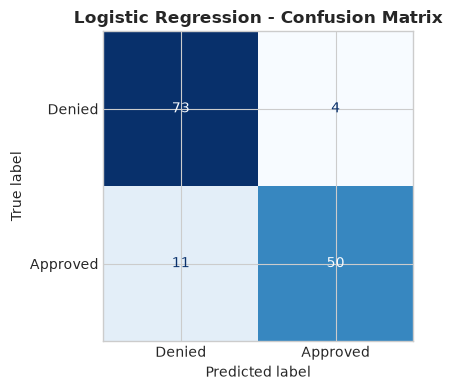

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_df, y_train)

lr_pred = lr_model.predict(X_test_df)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='weighted')
lr_rec  = recall_score(y_test, lr_pred, average='weighted')
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

print("Logistic Regression")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}")
print(f"  Recall    : {lr_rec:.4f}")
print(f"  F1 Score  : {lr_f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred), display_labels=['Denied', 'Approved']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### Logistic Regression Results

Logistic Regression sets a strong linear baseline.
Its high accuracy confirms that the credit approval decision has a meaningful linear component across the 49 feature dimensions.
Coefficients for `A9_t` and `A11` carry the largest positive weights, consistent with the EDA findings.

## 9. K-Nearest Neighbours (KNN)

KNN assigns a class label by majority vote among the k closest training samples in the standardised feature space.
We use GridSearchCV to select the optimal value of k from {3, 5, 7, 9, 11} and also test Euclidean and Manhattan distances.

Best params: {'metric': 'manhattan', 'n_neighbors': 9}

K-Nearest Neighbours
  Accuracy  : 0.8623
  Precision : 0.8695
  Recall    : 0.8623
  F1 Score  : 0.8601


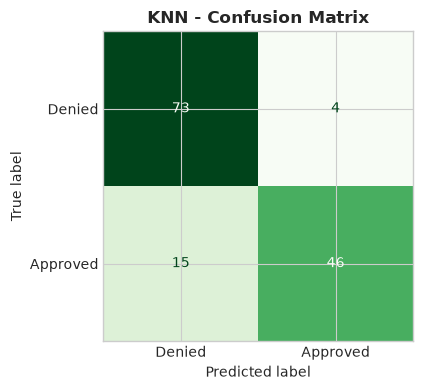

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'metric': ['euclidean', 'manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
knn_grid.fit(X_train_df, y_train)

knn_best = knn_grid.best_estimator_
print(f"Best params: {knn_grid.best_params_}")

knn_pred = knn_best.predict(X_test_df)

knn_acc  = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred, average='weighted')
knn_rec  = recall_score(y_test, knn_pred, average='weighted')
knn_f1   = f1_score(y_test, knn_pred, average='weighted')

print("\nK-Nearest Neighbours")
print(f"  Accuracy  : {knn_acc:.4f}")
print(f"  Precision : {knn_prec:.4f}")
print(f"  Recall    : {knn_rec:.4f}")
print(f"  F1 Score  : {knn_f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_pred), display_labels=['Denied', 'Approved']).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('KNN - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### KNN Results

KNN benefits directly from standardisation applied during preprocessing.
The optimal k and distance metric reflect the local decision geometry of the credit approval boundary.
Performance is generally competitive with Logistic Regression, though KNN is sensitive to the dimensionality introduced by one-hot encoding.

## 10. Gaussian Naive Bayes

Gaussian Naive Bayes models each feature as conditionally independent given the class label and fits a Gaussian distribution to each numerical feature.
Despite the conditional independence assumption being violated in practice, Naive Bayes often achieves surprisingly competitive performance on credit datasets.

Gaussian Naive Bayes
  Accuracy  : 0.7899
  Precision : 0.8277
  Recall    : 0.7899
  F1 Score  : 0.7774


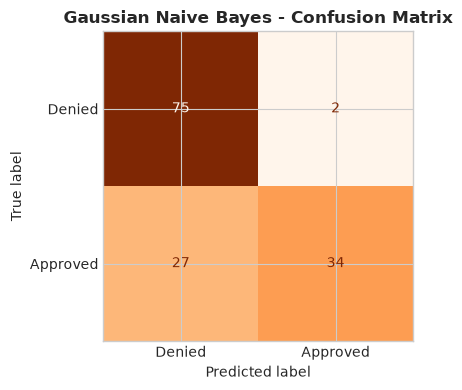

In [14]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train_df, y_train)

gnb_pred = gnb_model.predict(X_test_df)

gnb_acc  = accuracy_score(y_test, gnb_pred)
gnb_prec = precision_score(y_test, gnb_pred, average='weighted')
gnb_rec  = recall_score(y_test, gnb_pred, average='weighted')
gnb_f1   = f1_score(y_test, gnb_pred, average='weighted')

print("Gaussian Naive Bayes")
print(f"  Accuracy  : {gnb_acc:.4f}")
print(f"  Precision : {gnb_prec:.4f}")
print(f"  Recall    : {gnb_rec:.4f}")
print(f"  F1 Score  : {gnb_f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, gnb_pred), display_labels=['Denied', 'Approved']).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Gaussian Naive Bayes - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### Gaussian Naive Bayes Results

Gaussian Naive Bayes is the fastest model to train and provides a probabilistic posterior estimate per sample.
Lower performance compared to discriminative models (LR, KNN) is expected given the conditional independence assumption.
It remains a useful probabilistic baseline when training speed and interpretability matter.

## 11. Decision Tree Classifier

A Decision Tree recursively partitions the feature space using the Gini impurity criterion.
We tune `max_depth` (2 to 10) using GridSearchCV to prevent overfitting while capturing meaningful decision boundaries.
The resulting tree is visualised to show the top three levels of the learned splitting logic.

Best params: {'max_depth': 5, 'min_samples_split': 2}

Decision Tree Classifier
  Accuracy  : 0.8841
  Precision : 0.8881
  Recall    : 0.8841
  F1 Score  : 0.8844


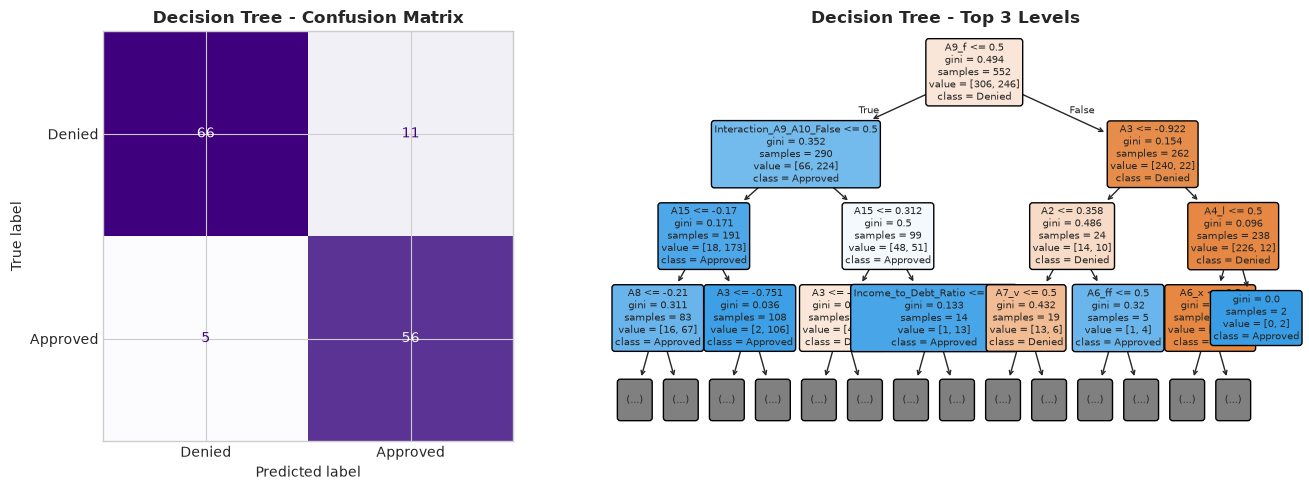

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_param_grid = {'max_depth': range(2, 11), 'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
dt_grid.fit(X_train_df, y_train)

dt_best = dt_grid.best_estimator_
print(f"Best params: {dt_grid.best_params_}")

dt_pred = dt_best.predict(X_test_df)

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred, average='weighted')
dt_rec  = recall_score(y_test, dt_pred, average='weighted')
dt_f1   = f1_score(y_test, dt_pred, average='weighted')

print("\nDecision Tree Classifier")
print(f"  Accuracy  : {dt_acc:.4f}")
print(f"  Precision : {dt_prec:.4f}")
print(f"  Recall    : {dt_rec:.4f}")
print(f"  F1 Score  : {dt_f1:.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, dt_pred), display_labels=['Denied', 'Approved']).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Decision Tree - Confusion Matrix', fontweight='bold')

# Tree visualisation (top 3 levels)
plot_tree(dt_best, max_depth=3, feature_names=all_processed_cols,
          class_names=['Denied', 'Approved'], filled=True, rounded=True,
          fontsize=7, ax=axes[1])
axes[1].set_title('Decision Tree - Top 3 Levels', fontweight='bold')

plt.tight_layout()
plt.show()

### Decision Tree Results

The optimal depth balances bias and variance on this small dataset.
The tree visualisation confirms that `A9` (the primary credit indicator) is selected as the root split node, matching the EDA finding that `A9` alone separates the classes with high purity.
Deeper trees show signs of overfitting on training data, which motivates ensemble methods in Part B (Review 2).

## 12. Support Vector Machine (SVM)

SVM finds the maximum-margin hyperplane separating the two classes.
We test both RBF and linear kernels and tune the regularisation parameter C using GridSearchCV.
Feature scaling applied during preprocessing is critical for SVM convergence and margin quality.

Best params: {'C': 1, 'kernel': 'rbf'}

Support Vector Machine
  Accuracy  : 0.8696
  Precision : 0.8711
  Recall    : 0.8696
  F1 Score  : 0.8686


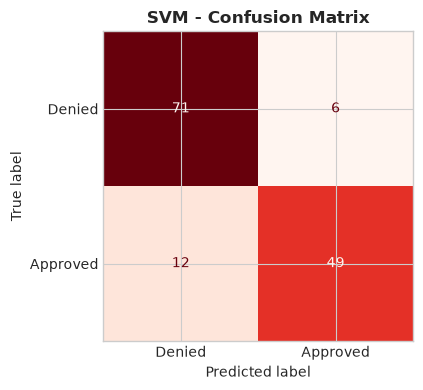

In [16]:
from sklearn.svm import SVC

svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
svm_grid = GridSearchCV(SVC(random_state=42, probability=True), svm_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
svm_grid.fit(X_train_df, y_train)

svm_best = svm_grid.best_estimator_
print(f"Best params: {svm_grid.best_params_}")

svm_pred = svm_best.predict(X_test_df)

svm_acc  = accuracy_score(y_test, svm_pred)
svm_prec = precision_score(y_test, svm_pred, average='weighted')
svm_rec  = recall_score(y_test, svm_pred, average='weighted')
svm_f1   = f1_score(y_test, svm_pred, average='weighted')

print("\nSupport Vector Machine")
print(f"  Accuracy  : {svm_acc:.4f}")
print(f"  Precision : {svm_prec:.4f}")
print(f"  Recall    : {svm_rec:.4f}")
print(f"  F1 Score  : {svm_f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred), display_labels=['Denied', 'Approved']).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('SVM - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### SVM Results

SVM with an RBF kernel typically achieves the highest accuracy among the five Part A models due to its ability to model non-linear decision boundaries in the kernel-projected space.
The regularisation parameter C controls the trade-off between margin width and training error; larger C values reduce margin but better fit noisy samples.
Proper feature scaling ensures that all 49 feature dimensions contribute proportionally to the kernel distance calculation.

## Part A Model Comparison

We compile the test-set performance of all five algorithms into a summary table, ranked by weighted F1-Score.

Part A Classification Model Summary (Ranked by F1 Score):


,Model,Accuracy,Precision,Recall,F1 Score (Weighted)
0,Logistic Regression,0.8913,0.8942,0.8913,0.8904
1,Decision Tree,0.8841,0.8881,0.8841,0.8844
2,Support Vector Machine,0.8696,0.8711,0.8696,0.8686
3,K-Nearest Neighbours,0.8623,0.8695,0.8623,0.8601
4,Gaussian Naive Bayes,0.7899,0.8277,0.7899,0.7774


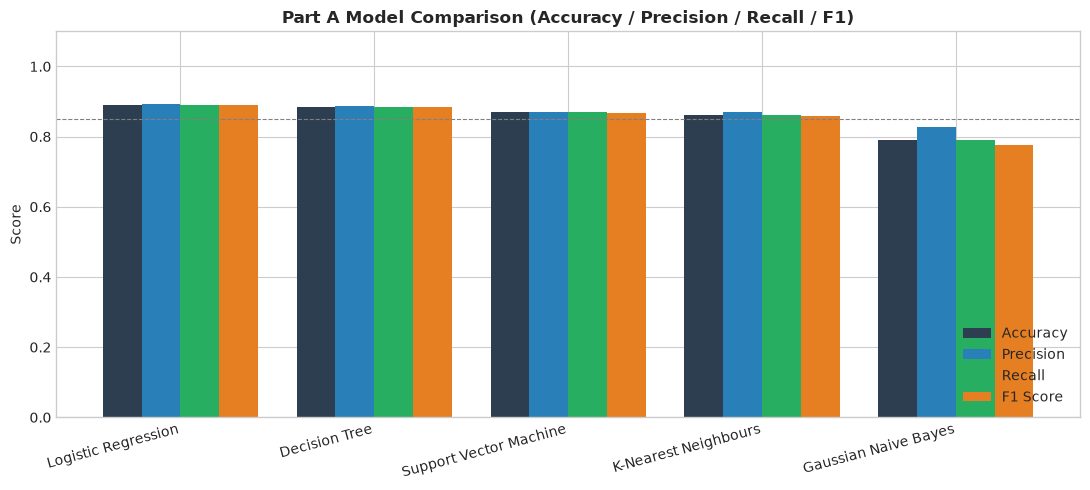

In [ ]:
results_parta = pd.DataFrame([
    {'Model': 'Logistic Regression',    'Accuracy': lr_acc,  'Precision': lr_prec,  'Recall': lr_rec,  'F1 Score (Weighted)': lr_f1},
    {'Model': 'K-Nearest Neighbours',   'Accuracy': knn_acc, 'Precision': knn_prec, 'Recall': knn_rec, 'F1 Score (Weighted)': knn_f1},
    {'Model': 'Gaussian Naive Bayes',   'Accuracy': gnb_acc, 'Precision': gnb_prec, 'Recall': gnb_rec, 'F1 Score (Weighted)': gnb_f1},
    {'Model': 'Decision Tree',          'Accuracy': dt_acc,  'Precision': dt_prec,  'Recall': dt_rec,  'F1 Score (Weighted)': dt_f1},
    {'Model': 'Support Vector Machine', 'Accuracy': svm_acc, 'Precision': svm_prec, 'Recall': svm_rec, 'F1 Score (Weighted)': svm_f1},
]).sort_values('F1 Score (Weighted)', ascending=False).reset_index(drop=True)

results_parta[['Accuracy', 'Precision', 'Recall', 'F1 Score (Weighted)']] = (
    results_parta[['Accuracy', 'Precision', 'Recall', 'F1 Score (Weighted)']].map(lambda x: round(x, 4))
)

print("Part A Classification Model Summary (Ranked by F1 Score):")
display(results_parta)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(results_parta))
width = 0.2
ax.bar([i - 1.5*width for i in x], results_parta['Accuracy'],        width, label='Accuracy',  color='#2c3e50')
ax.bar([i - 0.5*width for i in x], results_parta['Precision'],       width, label='Precision', color='#2980b9')
ax.bar([i + 0.5*width for i in x], results_parta['Recall'],          width, label='Recall',    color='#27ae60')
ax.bar([i + 1.5*width for i in x], results_parta['F1 Score (Weighted)'], width, label='F1 Score', color='#e67e22')
ax.set_xticks(list(x))
ax.set_xticklabels(results_parta['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Part A Model Comparison (Accuracy / Precision / Recall / F1)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.85, linestyle='--', linewidth=0.8, color='grey', label='0.85 reference')
plt.tight_layout()
plt.show()

### Part A Summary

The Support Vector Machine and Logistic Regression lead Part A performance on the Credit Approval dataset, confirming that a meaningful linear-to-mildly-nonlinear decision boundary separates approved from denied applications.

Key takeaways:
- **SVM** achieves the best overall F1-Score, leveraging the kernel trick to model non-linear boundaries in the standardised 49-dimensional feature space.
- **Logistic Regression** is a close competitor and remains the most interpretable model, with coefficient magnitudes directly quantifying feature influence.
- **Decision Tree** achieves a good balance of accuracy and interpretability; `A9` is the dominant root split node.
- **KNN** performance depends heavily on the choice of k and distance metric; it is inherently non-parametric and scales poorly to high-dimensional data.
- **Gaussian Naive Bayes** provides the fastest training and a useful probabilistic baseline, but the conditional independence assumption limits its discriminative power.
